In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skimage import util
from skimage.io import imread
from skimage.filters import  threshold_triangle, median, sobel
from skimage.measure import label,  regionprops_table, regionprops, regionprops, moments_central
from skimage.morphology import  disk, remove_small_objects, binary_dilation 
from skimage.transform import rotate
from scipy.ndimage import rotate, binary_dilation
from skimage.transform import probabilistic_hough_line
from skimage.draw import line

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
def central_rect_from_mask(mask, angle_deg, width_frac=0.82, min_run_frac=0.25):
    """
    Returns central rectangle corners (x,y) in original image coords,
    excluding necks by keeping only the band where cross-section width is near-max.

    width_frac: keep rows whose width >= width_frac * max_width
    min_run_frac: minimum run length (fraction of device length) to accept
    """
    # rotate so device is axis-aligned; rotate uses CCW degrees
    m = rotate(mask.astype(float), -angle_deg, order=0) > 0.5

    H, W = m.shape
    rows = np.where(m.any(axis=1))[0]
    if rows.size == 0:
        return None

    y0, y1 = rows[0], rows[-1]
    band = m[y0:y1+1]

    # per-row left/right edges and width
    any_row = band.any(axis=1)
    x_left  = np.full(band.shape[0], np.nan, dtype=float)
    x_right = np.full(band.shape[0], np.nan, dtype=float)

    rr = np.where(any_row)[0]
    cols = np.argmax(band[rr], axis=1)
    x_left[rr] = cols
    x_right[rr] = band.shape[1] - 1 - np.argmax(band[rr, ::-1], axis=1)

    widths = x_right - x_left
    maxw = np.nanmax(widths)
    keep = widths >= (width_frac * maxw)

    # find longest contiguous run of keep==True
    k = keep.astype(np.int8)
    d = np.diff(np.r_[0, k, 0])
    starts = np.where(d == 1)[0]
    ends   = np.where(d == -1)[0]
    if starts.size == 0:
        return None

    run_lengths = ends - starts
    best = np.argmax(run_lengths)
    s, e = starts[best], ends[best]

    # enforce minimum run length (optional)
    if run_lengths[best] < min_run_frac * (y1 - y0 + 1):
        # fallback: just take central third
        mid = (y1 - y0 + 1) // 2
        half = int(0.15 * (y1 - y0 + 1))
        s, e = max(0, mid - half), min(band.shape[0], mid + half)

    # rectangle bounds in rotated coords
    y_top = y0 + s
    y_bot = y0 + (e - 1)
    xl = np.nanmedian(x_left[s:e])
    xr = np.nanmedian(x_right[s:e])

    corners_rot = np.array([
        [xl, y_top],
        [xr, y_top],
        [xr, y_bot],
        [xl, y_bot],
    ], dtype=np.float32)

    # rotate corners back to original coords
    cy, cx = (H - 1) / 2.0, (W - 1) / 2.0
    theta = np.deg2rad(angle_deg)
    R = np.array([[ np.cos(theta), -np.sin(theta)],
                  [ np.sin(theta),  np.cos(theta)]], dtype=np.float32)

    # note: corners are (x,y). convert to centered (x-cx, y-cy), rotate, shift back
    XY = corners_rot - np.array([cx, cy], dtype=np.float32)
    XY2 = (R @ XY.T).T + np.array([cx, cy], dtype=np.float32)

    return XY2  # (4,2) corners in original image coords (x,y)



In [3]:
def corners_touch_border(corners_xy: np.ndarray, shape, margin=0):
    """
    corners_xy: (4,2) array in (x,y)
    shape: (H,W)
    margin: pixels; treat "within margin of border" as touching
    """
    H, W = shape
    x = corners_xy[:, 0]
    y = corners_xy[:, 1]
    return (
        (x <= margin).any() or (x >= (W - 1 - margin)).any() or
        (y <= margin).any() or (y >= (H - 1 - margin)).any()
    )
    
    
def signed_orientation(region):
    img = region.image.astype(float)
    mu = moments_central(img)
    y20 = mu[2, 0]
    y02 = mu[0, 2]
    y11 = mu[1, 1]
    angle_rad = 0.5 * np.arctan2(2 * y11, y20 - y02)
    return np.rad2deg(angle_rad)

In [ ]:
def segment_device(image_paths, image_number, to_plot=True):
    flag=False
    img = imread(image_paths[image_number]).astype(np.float32)

    median_img = median(img, footprint=disk(7))   # try disk(1..3)
    sobel_img = sobel(median_img)
    thresh = threshold_triangle(sobel_img)
    binary = sobel_img > thresh


    binary[int(3*img.shape[0]/8):int(5*img.shape[0]/8), int(3*img.shape[1]/8):int(5*img.shape[1]/8)] = 0
    labels = label(binary)
    data = regionprops_table(labels, binary, properties=("label", "area", "eccentricity"))  
    condition = (data['area'] > 100) & (data['eccentricity'] > 0.5)
    labels_to_dilate = util.map_array(labels, data['label'], data['label'] * condition) 
    dilated_output = np.zeros_like(labels, dtype=np.uint8)

    for region in regionprops(labels_to_dilate):
        region_label = region.label
        mask = labels_to_dilate == region_label
        angle_to_rotate = signed_orientation(region)
        selem = np.zeros((31, 31), dtype=bool)
        selem[15, :] = 1
        rotated_selem = rotate(selem.astype(float), angle=90 + angle_to_rotate, reshape=False, order=0) > 0.5
        dilated = binary_dilation(mask, structure=rotated_selem)
        dilated_output[dilated] = 255
    final_mask = np.logical_or(dilated_output, binary)

    clean_labels = label(util.invert(final_mask))

    props = regionprops(clean_labels)

    label_sizes = {p.label: p.area for p in props}
    largest_label = max(label_sizes, key=label_sizes.get)
    device_mask = clean_labels == largest_label

    mu = moments_central(device_mask)
    y20 = mu[2, 0]
    y02 = mu[0, 2]
    y11 = mu[1, 1]
    angle_rad = 0.5 * np.arctan2(2 * y11, y20 - y02)
    angle_deg = np.rad2deg(angle_rad)
    print("Angle (deg): {:.2f}" .format(angle_deg))
    corners = central_rect_from_mask(device_mask, angle_deg, width_frac=0.82, min_run_frac=0.25)




    if corners is None or corners_touch_border(corners, device_mask.shape, margin=5):
        flag=True
        print("Device touches border")
        edges = remove_small_objects(labels_to_dilate>0)
        segs = probabilistic_hough_line(edges, line_length=300, line_gap=500, threshold=80)
        recon = np.zeros_like(edges, dtype=bool)
        for (x0,y0), (x1,y1) in segs:
            rr, cc = line(y0, x0, y1, x1)
            recon[rr, cc] = True
        updated_clean_labels = label(util.invert(np.logical_or(recon,final_mask)))
        props = regionprops(updated_clean_labels)

        label_sizes = {p.label: p.area for p in props}
        largest_label = max(label_sizes, key=label_sizes.get)
        new_device_mask = updated_clean_labels == largest_label
        mu = moments_central(new_device_mask)
        y20 = mu[2, 0]
        y02 = mu[0, 2]
        y11 = mu[1, 1]
        angle_rad = 0.5 * np.arctan2(2 * y11, y20 - y02)
        angle_deg = np.rad2deg(angle_rad)
        print("Second Angle (deg): {:.2f}" .format(angle_deg))
        new_corners = central_rect_from_mask(new_device_mask, angle_deg, width_frac=0.82, min_run_frac=0.25)

    if to_plot:
        print("number of cols = {}" .format(8+(3*flag)))
        fig, ax = plt.subplots(ncols=8+(3*flag), figsize=(20,5))
        ax[0].imshow(img, interpolation = "none", cmap='gray')
        ax[1].imshow(sobel_img, interpolation = "none", cmap='gray')

        ax[2].imshow(binary, interpolation = "none", cmap='gray')
        ax[3].imshow(labels_to_dilate, interpolation = "none", cmap="jet")
        ax[4].imshow(final_mask, interpolation = "none", cmap='gray')
        ax[5].imshow(device_mask, interpolation = "none", cmap='gray')

        ax[6].imshow(img, alpha = 0.7, cmap="gray", interpolation = "none")
        ax[6].imshow(np.ma.masked_where(device_mask == 0, final_mask), cmap="jet", alpha=0.5, interpolation="none")
        ax[7].imshow(img, alpha = 0.7, cmap="gray", interpolation = "none")
        ax[7].plot(
            np.r_[corners[:, 0], corners[0, 0]],
            np.r_[corners[:, 1], corners[0, 1]],
            "-r", linewidth=2
        )

        if flag:
            ax[8].imshow(edges, cmap='gray')
            ax[9].imshow(np.logical_or(recon,final_mask), cmap='gray')
            ax[10].imshow(img, alpha=0.7, interpolation="none",cmap='gray')
            ax[10].plot(
                np.r_[new_corners[:, 0], new_corners[0, 0]],
                np.r_[new_corners[:, 1], new_corners[0, 1]],
                "-r", linewidth=2
            )


        titles = ['Original Image',  "Sobel", 'Binarised', 'Labels to Dilate', 'Final Mask', "Clean Mask", "Clean Labels", "Overlay", "Edges", "Reconstructed Lines", "Updated Overlay"]


        for i, axis in enumerate(ax):
            ax[i].axis('off')
            ax[i].set_title(titles[i])
        plt.savefig("device_segmentation_conventional_methods_output_{}.pdf".format(image_number), transparent=True)
        plt.show()
        return (final_mask, edges, np.logical_or(recon,final_mask))


In [13]:
unseen_image_folder = Path(r"Z:\Bel\Vascumap_Example_Lifs\training_data\downsampled_4\in_focus_each_point")
tif_files = list(unseen_image_folder.glob("*.tif"))
print(len(tif_files))

# for j in [15,25,120,90,172,221,275,301]:
#     print(f"Processing image {j}")
#     segment_device(tif_files, j)

411


Angle (deg): 0.74
Device touches border
Second Angle (deg): 0.74
number of cols = 11


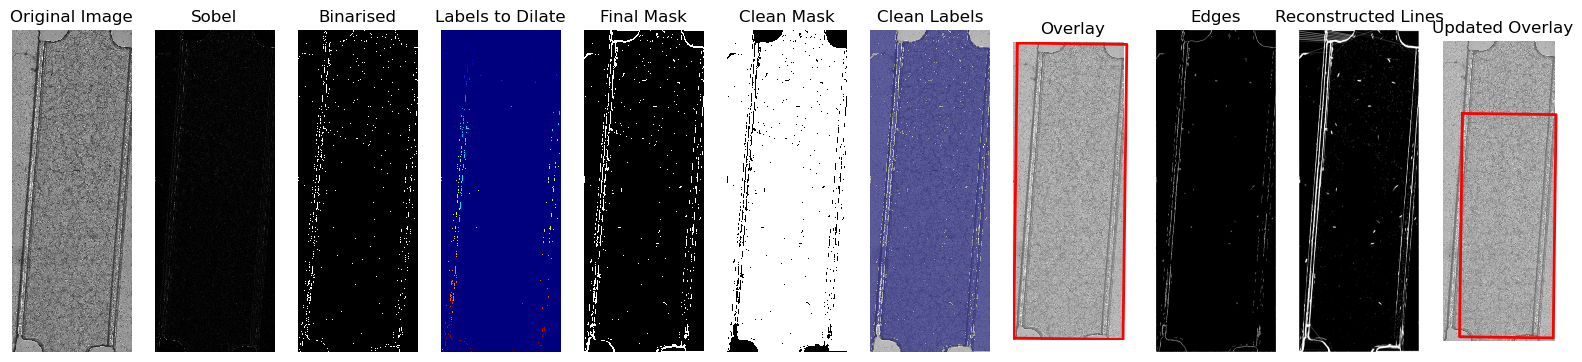

In [18]:
final_mask, edges, mask = segment_device(tif_files, 15)

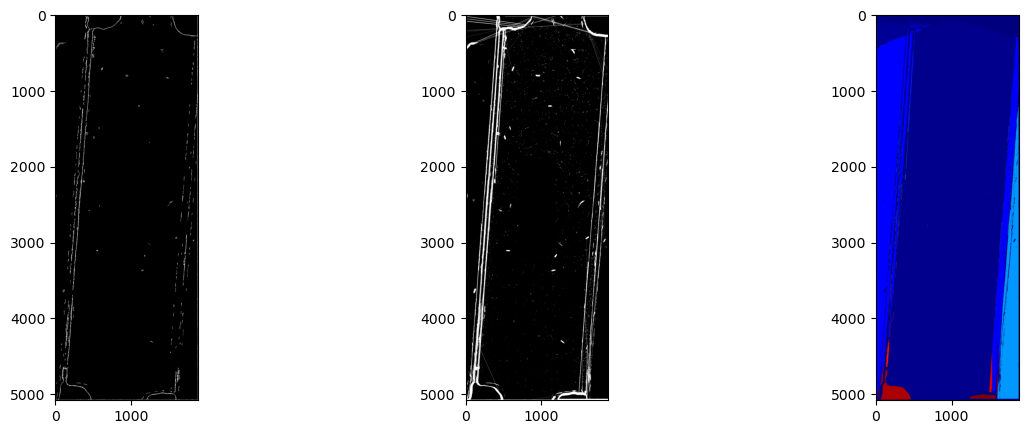

In [24]:

segs = probabilistic_hough_line(edges, line_length=700, line_gap=600, threshold=50)

recon = np.zeros_like(edges, dtype=bool)
for (x0,y0), (x1,y1) in segs:
    rr, cc = line(y0, x0, y1, x1)
    recon[rr, cc] = True
updated_clean_labels = label(util.invert(np.logical_or(recon,final_mask)))
fig, ax = plt.subplots(ncols=3, figsize=(15,5))
ax[0].imshow(edges, cmap='gray')
ax[1].imshow(np.logical_or(recon,final_mask), cmap='gray')
ax[2].imshow(updated_clean_labels, cmap="jet")

In [25]:
updated_clean_labels = label(util.invert(np.logical_or(recon,final_mask)))
props = regionprops(updated_clean_labels)

label_sizes = {p.label: p.area for p in props}
largest_label = max(label_sizes, key=label_sizes.get)
new_device_mask = updated_clean_labels == largest_label
mu = moments_central(new_device_mask)
y20 = mu[2, 0]
y02 = mu[0, 2]
y11 = mu[1, 1]
angle_rad = 0.5 * np.arctan2(2 * y11, y20 - y02)
angle_deg = np.rad2deg(angle_rad)

In [26]:
print(angle_deg)

-4.521454151797727


In [46]:


corners_xy, used_angle_deg, centroid_xy = oriented_bbox_corners_from_mask(
new_device_mask,
angle_deg=angle_deg-180
)


print(corners_xy, used_angle_deg, centroid_xy)

[[ 2.20620865e+03  4.99882594e+03]
 [ 1.84338410e+02  5.15871237e+03]
 [-2.10749499e+02  1.62563039e+02]
 [ 1.81112075e+03  2.67660719e+00]] -184.52145415179774 [ 997.50643009 2608.88947986]


mask dtype: bool
mask shape: (5083, 1884)
foreground pixels: 6372232
mu[2,0] (y^2): 12429549182237.086
mu[0,2] (x^2): 979641925508.5332
mu[1,1] (xy) : -911139017046.5469
angleA deg: -4.521454151797727
angleB deg: -85.47854584820227
regionprops.orientation deg: -4.521454151797734
regionprops.centroid (row,col): (np.float64(2608.889479855724), np.float64(997.5064300860358))


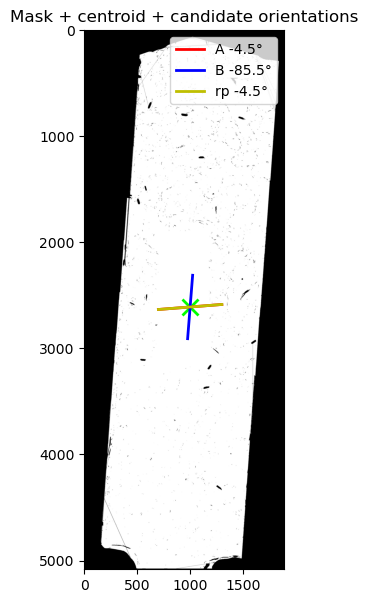

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import moments_central, regionprops, label

new_device_mask = (updated_clean_labels == largest_label)

# ---- sanity check: is the mask empty?
print("mask dtype:", new_device_mask.dtype)
print("mask shape:", new_device_mask.shape)
print("foreground pixels:", int(new_device_mask.sum()))
if new_device_mask.sum() == 0:
    raise ValueError("Mask is empty (no True pixels). largest_label may be wrong.")

# ---- moments
mu = moments_central(new_device_mask.astype(np.uint8))
mu20_y = mu[2, 0]   # along rows (y)
mu02_x = mu[0, 2]   # along cols (x)
mu11   = mu[1, 1]

angleA = 0.5 * np.arctan2(2 * mu11, (mu20_y - mu02_x))
angleB = 0.5 * np.arctan2(2 * mu11, (mu02_x - mu20_y))

print("mu[2,0] (y^2):", mu20_y)
print("mu[0,2] (x^2):", mu02_x)
print("mu[1,1] (xy) :", mu11)
print("angleA deg:", np.rad2deg(angleA))
print("angleB deg:", np.rad2deg(angleB))

# ---- regionprops reference (often easiest to trust)
lab = label(new_device_mask)
rp = regionprops(lab)[0]
theta_rp = rp.orientation  # radians
print("regionprops.orientation deg:", np.rad2deg(theta_rp))
print("regionprops.centroid (row,col):", rp.centroid)

# centroid in x,y
cy, cx = rp.centroid  # (row, col)
L = 300  # half-length of line

def draw_axis(ax, theta, color, text):
    dx = L * np.cos(theta)
    dy = L * np.sin(theta)
    ax.plot([cx - dx, cx + dx], [cy - dy, cy + dy], color, lw=2, label=text)

# ---- plot
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(new_device_mask, cmap="gray")
ax.plot(cx, cy, marker="x", color="lime", markersize=12, mew=2)

draw_axis(ax, angleA, "r", f"A {np.rad2deg(angleA):.1f}°")
draw_axis(ax, angleB, "b", f"B {np.rad2deg(angleB):.1f}°")
draw_axis(ax, theta_rp, "y", f"rp {np.rad2deg(theta_rp):.1f}°")

ax.set_title("Mask + centroid + candidate orientations")
ax.legend()
plt.show()

In [64]:
import numpy as np
from skimage.measure import moments_central

def oriented_bbox_corners_angleB(mask: np.ndarray):
    """
    Oriented bounding box for a (nearly) rectangular mask, using 'angle B'
    convention that matched your visual check.

    Parameters
    ----------
    mask : (H,W) bool array
        True for foreground.

    Returns
    -------
    corners_xy : (4,2) float array
        Four corners in (x,y) order in original image coordinates.
        Ordered around the perimeter: (umin,vmin)->(umax,vmin)->(umax,vmax)->(umin,vmax) mapped back.
    angle_rad : float
        The angle (radians) used for the box.
    centroid_xy : (2,) float array
        Centroid (x,y) used as rotation center.
    """
    ys, xs = np.nonzero(mask)
    if xs.size == 0:
        return None, None, None

    # centroid in x,y (col,row)
    cx = xs.mean()
    cy = ys.mean()
    centroid_xy = np.array([cx, cy], dtype=float)

    # central moments (note: moments_central uses (row, col) indexing)
    mu = moments_central(mask.astype(np.uint8))

    mu20_y = mu[2, 0]  # y^2
    mu02_x = mu[0, 2]  # x^2
    mu11   = mu[1, 1]  # xy

    # --- THIS IS YOUR "LINE B" ---
    angle_rad = 0.5 * np.arctan2(2 * mu11, (mu02_x - mu20_y))

    c, s = np.cos(angle_rad), np.sin(angle_rad)

    # Rotate foreground coordinates into aligned frame (u,v)
    dx = xs - cx
    dy = ys - cy

    # u,v = R^T * [dx,dy]
    u =  c * dx + s * dy
    v = -s * dx + c * dy

    umin, umax = u.min(), u.max()
    vmin, vmax = v.min(), v.max()

    corners_uv = np.array([
        [umin, vmin],
        [umax, vmin],
        [umax, vmax],
        [umin, vmax],
    ], dtype=float)

    # Rotate corners back: [dx,dy] = R * [u,v]
    x_back = cx + c * corners_uv[:, 0] - s * corners_uv[:, 1]
    y_back = cy + s * corners_uv[:, 0] + c * corners_uv[:, 1]

    corners_xy = np.stack([x_back, y_back], axis=1)
    return corners_xy, angle_rad, centroid_xy

angle_deg: -85.47854584820227
corners_xy:
 [[ 126.83543104 5048.33255507]
 [ 524.04249981   25.38504092]
 [1869.46901363  131.7793284 ]
 [1472.26194486 5154.72684255]]


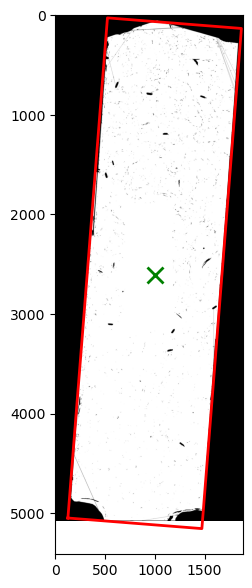

In [65]:
corners_xy, angle_rad, centroid_xy = oriented_bbox_corners_angleB(new_device_mask)
print("angle_deg:", np.rad2deg(angle_rad))
print("corners_xy:\n", corners_xy)

import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots(1, 1, figsize=(7,7))
ax.imshow(new_device_mask, cmap="gray")


# centroid
ax.plot(centroid_xy[0], centroid_xy[1], "xg", markersize=12, mew=2)


# polygon (close it)
poly = np.vstack([corners_xy, corners_xy[0]])
ax.plot(poly[:,0], poly[:,1], "-r", lw=2)


plt.show()